In [16]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, BatchNormalization, MaxPooling2D,
                                     Dropout, GlobalAveragePooling2D, Dense,
                                     Input)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, CSVLogger)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


emotion
Angry       4953
Disgust      547
Fear        5121
Happy       8989
Sad         6077
Surprise    4002
Neutral     6198
Name: count, dtype: int64


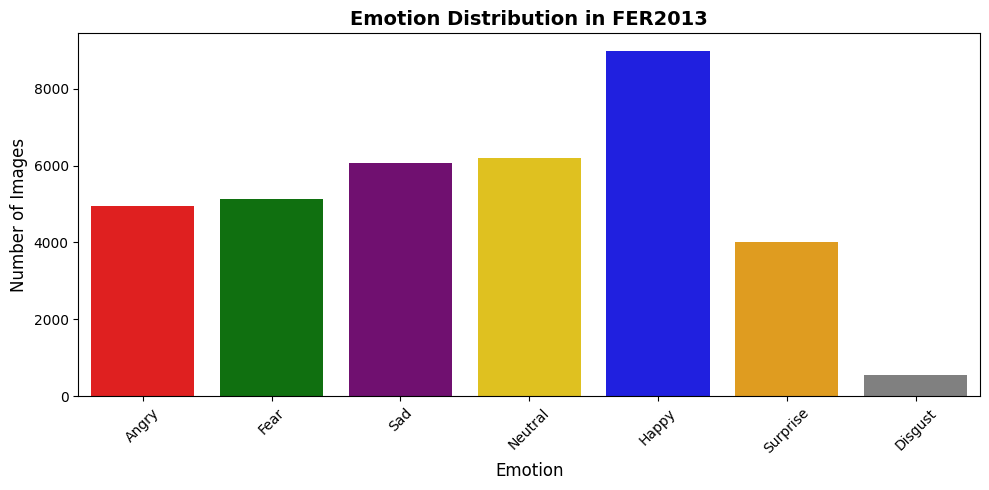


 Class Imbalance Note:
  - Most frequent: Happy (8989 images)
  - Least frequent: Disgust (547 images)
  - Ratio: 16.4:1


In [4]:
# Display class distribution
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy',
               4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

print(df['emotion'].value_counts().sort_index().rename(emotion_map))

plt.figure(figsize=(10, 5))
colors = ['red', 'green', 'purple', 'gold', 'blue', 'orange', 'gray']
sns.countplot(x=df['emotion'].map(emotion_map), palette=colors)
plt.title("Emotion Distribution in FER2013", fontsize=14, fontweight='bold')
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print class imbalance
print("\n Class Imbalance Note:")
print(f"  - Most frequent: Happy ({df['emotion'].value_counts().max()} images)")
print(f"  - Least frequent: Disgust ({df['emotion'].value_counts().min()} images)")
print(f"  - Ratio: {df['emotion'].value_counts().max() / df['emotion'].value_counts().min():.1f}:1")

In [5]:
# Convert pixels to images
pixels = df['pixels'].tolist()
images = []

for p in pixels:
    img = np.array(p.split(), dtype='float32')
    img = img.reshape(48, 48)
    images.append(img)

X = np.array(images)
X = X / 255.0  # Normalization to [0, 1]
X = np.expand_dims(X, -1)  # Shape: (48, 48, 1)

# One-hot encode labels
y = to_categorical(df['emotion'], num_classes=7)

print(f" X shape: {X.shape}")
print(f" y shape: {y.shape}")

 X shape: (35887, 48, 48, 1)
 y shape: (35887, 7)


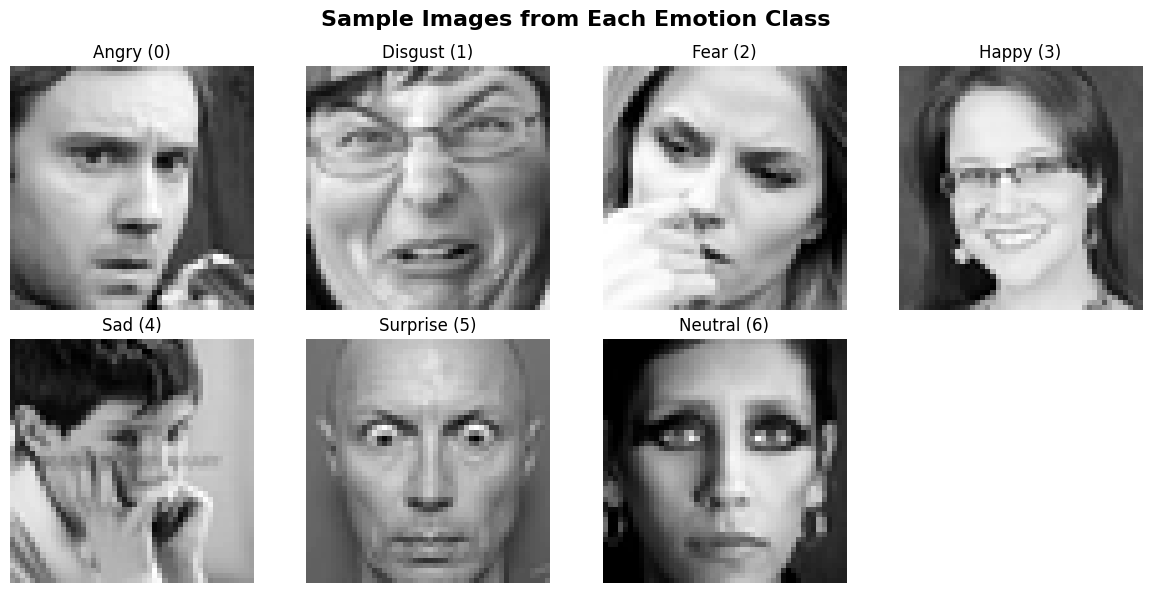

In [6]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i, emotion_id in enumerate(range(7)):
    idx = np.where(df['emotion'] == emotion_id)[0][0]
    axes[i].imshow(X[idx].reshape(48, 48), cmap='gray')
    axes[i].set_title(f"{emotion_map[emotion_id]} ({emotion_id})", fontsize=12)
    axes[i].axis('off')

axes[7].axis('off')  # Hide extra subplot
plt.suptitle("Sample Images from Each Emotion Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Split data: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['emotion']
)

print(f" Training set: {X_train.shape[0]} images")
print(f" Validation set: {X_val.shape[0]} images")

 Training set: 28709 images
 Validation set: 7178 images


In [9]:
# Compute class weights to handle imbalance
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['emotion']),
    y=df['emotion']
)
class_weights = dict(enumerate(class_weights_array))

print(" Class Weights (to balance training):")
for k, v in class_weights.items():
    print(f"  {emotion_map[k]}: {v:.3f}")

 Class Weights (to balance training):
  Angry: 1.035
  Disgust: 9.372
  Fear: 1.001
  Happy: 0.570
  Sad: 0.844
  Surprise: 1.281
  Neutral: 0.827


In [10]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # No augmentation for validation

train_datagen.fit(X_train)
val_datagen.fit(X_val)

print(" Data Augmentation configured for training set")

 Data Augmentation configured for training set


In [12]:
# Build CNN Model
def build_model(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(64, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 2
        Conv2D(128, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # Block 3
        Conv2D(256, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Conv2D(256, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.35),

        # Block 4
        Conv2D(512, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Conv2D(512, (3, 3), padding='same', activation='relu',
               kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        GlobalAveragePooling2D(),
        Dropout(0.4),

        # Fully Connected
        Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
        BatchNormalization(),
        Dropout(0.5),

        # Output
        Dense(num_classes, activation='softmax')
    ])

    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,858,567 (18.53 MB)

 Trainable params: 4,853,959 (18.52 MB)

 Non-trainable params: 4,608 (18.00 KB)

In [13]:
# Compile Model
optimizer = AdamW(learning_rate=0.001, weight_decay=1e-5)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")

 Model compiled successfully!


In [17]:
# Callbacks
checkpoint = ModelCheckpoint(
    filepath='/kaggle/working/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

csv_logger = CSVLogger('/kaggle/working/training_history.csv')

callbacks = [checkpoint, early_stop, reduce_lr, csv_logger]
print(" Callbacks configured")

 Callbacks configured


In [19]:
# Train the Model
batch_size = 64
epochs = 100

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=val_datagen.flow(X_val, y_val, batch_size=batch_size),
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1483 - loss: 3.5291
Epoch 1: val_accuracy improved from -inf to 0.13709, saving model to /kaggle/working/best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.1483 - loss: 3.5284 - val_accuracy: 0.1371 - val_loss: 3.0522 - learning_rate: 0.0010
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1379 - loss: 2.9090
Epoch 2: val_accuracy improved from 0.13709 to 0.17958, saving model to /kaggle/working/best_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.1379 - loss: 2.9089 - val_accuracy: 0.1796 - val_loss: 2.5997 - learning_rate: 0.0010
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1505 - loss: 2.5696
Epoch 3: val_accuracy did not improve from 0.17958
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.1505 - loss: 2.5694 - val_accuracy: 0.0997 - val_loss: 2.3832 - learning_rate: 0.0010
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/

In [21]:
# Load the best model from first training
from tensorflow.keras.models import load_model

model = load_model('/kaggle/working/best_model.keras')
print(" Loaded best model (Validation Accuracy: 0.6778)")

# Freeze early layers to protect learned features
for layer in model.layers[:8]:  # Freeze first 2 conv blocks
    layer.trainable = False

print(" Frozen first 2 convolutional blocks")

# Compile with LOW learning rate
model.compile(
    optimizer=AdamW(learning_rate=0.00001, weight_decay=1e-5),  # Very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define warmup + gentle cosine scheduler
def warmup_cosine(epoch, lr):
    """
    Warmup for 5 epochs, then low-amplitude cosine cycles.
    Max LR never exceeds 0.00005 (20x lower than original 0.001)
    """
    if epoch < 5:
        # Gradual warmup: 0.00002 → 0.00005
        return float(0.00001 + (0.00004 * epoch / 5))
    else:
        # Gentle cosine between 0.00001 and 0.00005
        T_0 = 15
        cycle_epoch = epoch - 5
        max_lr = 0.00005
        min_lr = 0.00001
        cosine_val = 0.5 * (1 + np.cos(np.pi * (cycle_epoch % T_0) / T_0))
        return float(min_lr + (max_lr - min_lr) * cosine_val)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(warmup_cosine)

# Callbacks
checkpoint_v2 = ModelCheckpoint(
    filepath='/kaggle/working/best_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_v2 = EarlyStopping(
    monitor='val_accuracy',
    patience=18,
    restore_best_weights=True,
    verbose=1,
    mode='max',
    min_delta=0.001
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

callbacks_v2 = [checkpoint_v2, early_stop_v2, lr_scheduler, reduce_lr_v2]

print("\n Phase 1: Fine-tuning with FROZEN early layers")
print(f"Starting accuracy: 0.6778")
print(f"Max learning rate: 0.00005 (20x lower than original)")
print(f"Epochs: 100 → 150")
print("-" * 60)

# Phase 1: Train with frozen layers
history2 = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=64),
    epochs=150,
    initial_epoch=100,
    validation_data=val_datagen.flow(X_val, y_val, batch_size=64),
    callbacks=callbacks_v2,
    class_weight=class_weights,
    verbose=1
)

# Phase 2: Unfreeze all layers and fine-tune with even lower LR
print("\n Unfreezing all layers for final fine-tuning...")
for layer in model.layers:
    layer.trainable = True

model.compile(
    optimizer=AdamW(learning_rate=0.000005, weight_decay=1e-5),  # Ultra low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Learning rate: 0.000005 (ultra low)")
print(f"Epochs: 150 → 170")
print("-" * 60)

history3 = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=64),
    epochs=170,
    initial_epoch=150,
    validation_data=val_datagen.flow(X_val, y_val, batch_size=64),
    callbacks=[checkpoint_v2, early_stop_v2, reduce_lr_v2],
    class_weight=class_weights,
    verbose=1
)

# Final evaluation
print("\n" + "="*60)
print(" TRAINING COMPLETE")
print("="*60)

# Load best model from this training
best_model_v2 = load_model('/kaggle/working/best_model_v2.keras')
val_loss, val_acc = best_model_v2.evaluate(X_val, y_val, verbose=0)

print(f"Best Validation Accuracy: {val_acc:.4f}")
if val_acc > 0.6778:
    print(f" IMPROVED! +{val_acc - 0.6778:.4f} over original")
else:
    print(f" No improvement, original 0.6778 is still best")
    print(f"Using original model for final report")
    best_model_v2 = load_model('/kaggle/working/best_model.keras')

 Loaded best model (Validation Accuracy: 0.6778)
 Frozen first 2 convolutional blocks

 Phase 1: Fine-tuning with FROZEN early layers
Starting accuracy: 0.6778
Max learning rate: 0.00005 (20x lower than original)
Epochs: 100 → 150
------------------------------------------------------------
Epoch 101/150
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6927 - loss: 0.9341
Epoch 101: val_accuracy improved from -inf to 0.67400, saving model to /kaggle/working/best_model_v2.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 43s 63ms/step - accuracy: 0.6927 - loss: 0.9342 - val_accuracy: 0.6740 - val_loss: 1.0689 - learning_rate: 4.0000e-05
Epoch 102/150
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6857 - loss: 0.9427
Epoch 102: val_accuracy did not improve from 0.67400
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.6857 - loss: 0.9427 - val_accuracy: 0.6718 - val_loss: 1.0811 - learning_rate: 3.6180e-05
Epoch 103/150
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6864

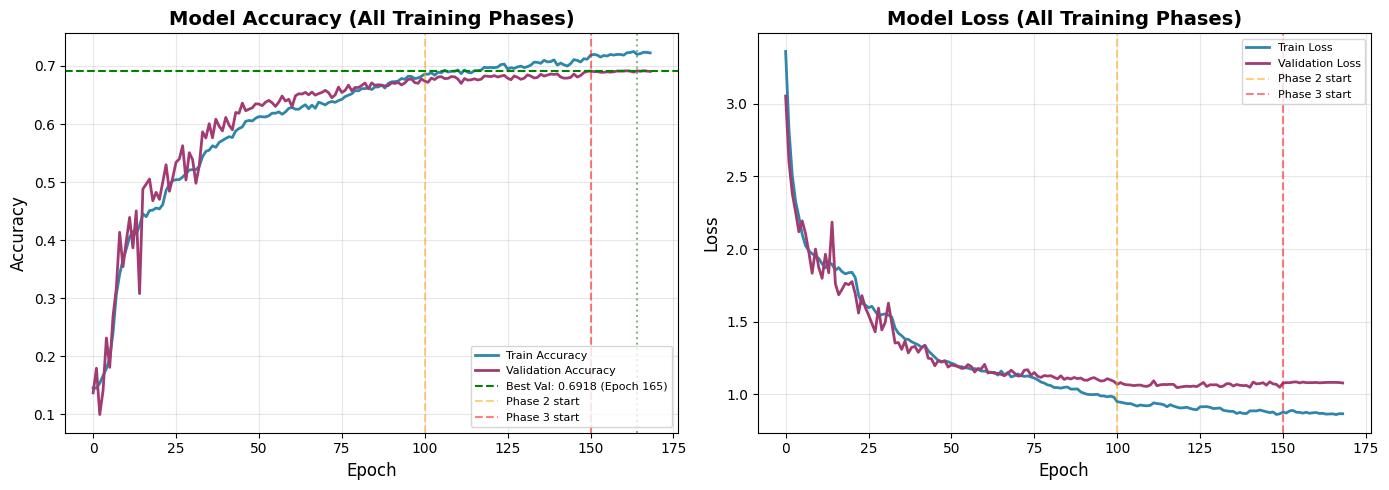


 Phase 1 (Epochs 1-100):   Best Val Acc = 0.6778
 Phase 2 (Epochs 101-150): Best Val Acc = 0.6907
 Phase 3 (Epochs 151-169): Best Val Acc = 0.6918
 OVERALL Best:              0.6918 at Epoch 165
 Train-Val Gap:             0.0319


In [32]:
# Combine all training histories
full_acc = history.history['accuracy'] + history2.history['accuracy'] + history3.history['accuracy']
full_val_acc = history.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
full_loss = history.history['loss'] + history2.history['loss'] + history3.history['loss']
full_val_loss = history.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss']

# Find best epoch
best_epoch = np.argmax(full_val_acc)
best_acc = full_val_acc[best_epoch]

# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(full_acc, label='Train Accuracy', linewidth=2, color='#2E86AB')
axes[0].plot(full_val_acc, label='Validation Accuracy', linewidth=2, color='#A23B72')
axes[0].axhline(y=best_acc, color='green', linestyle='--', 
                label=f'Best Val: {best_acc:.4f} (Epoch {best_epoch+1})')
axes[0].axvline(x=best_epoch, color='green', linestyle=':', alpha=0.5)
# Mark phase transitions
axes[0].axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='Phase 2 start')
axes[0].axvline(x=150, color='red', linestyle='--', alpha=0.5, label='Phase 3 start')
axes[0].set_title('Model Accuracy (All Training Phases)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(full_loss, label='Train Loss', linewidth=2, color='#2E86AB')
axes[1].plot(full_val_loss, label='Validation Loss', linewidth=2, color='#A23B72')
axes[1].axvline(x=100, color='orange', linestyle='--', alpha=0.5, label='Phase 2 start')
axes[1].axvline(x=150, color='red', linestyle='--', alpha=0.5, label='Phase 3 start')
axes[1].set_title('Model Loss (All Training Phases)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print metrics
print(f"\n Phase 1 (Epochs 1-100):   Best Val Acc = {max(history.history['val_accuracy']):.4f}")
print(f" Phase 2 (Epochs 101-150): Best Val Acc = {max(history2.history['val_accuracy']):.4f}")
print(f" Phase 3 (Epochs 151-169): Best Val Acc = {max(history3.history['val_accuracy']):.4f}")
print(f" OVERALL Best:              {best_acc:.4f} at Epoch {best_epoch+1}")
print(f" Train-Val Gap:             {abs(full_acc[-1] - full_val_acc[-1]):.4f}")

 Evaluating best_model_v2.keras (69.18%)
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Angry     0.5950    0.6256    0.6099       991
     Disgust     0.4477    0.7064    0.5480       109
        Fear     0.5887    0.4473    0.5083      1024
       Happy     0.9137    0.8660    0.8892      1798
         Sad     0.6044    0.5452    0.5733      1216
    Surprise     0.7418    0.8475    0.7911       800
     Neutral     0.6207    0.7363    0.6736      1240

    accuracy                         0.6918      7178
   macro avg     0.6446    0.6820    0.6562      7178
weighted avg     0.6941    0.6918    0.6894      7178

 Raw Confusion Matrix:
[[ 620   40   45   15  118   32  121]
 [  16   77    5    0    5    0    6]
 [ 151   15  458   13  162  118  107]
 [  40    9   27 1557   24   50   91]
 [ 133   20  128   36  663   16  220]
 [  16    4   61   21    7  678   13]
 [  66    7   54   62  118   20  913

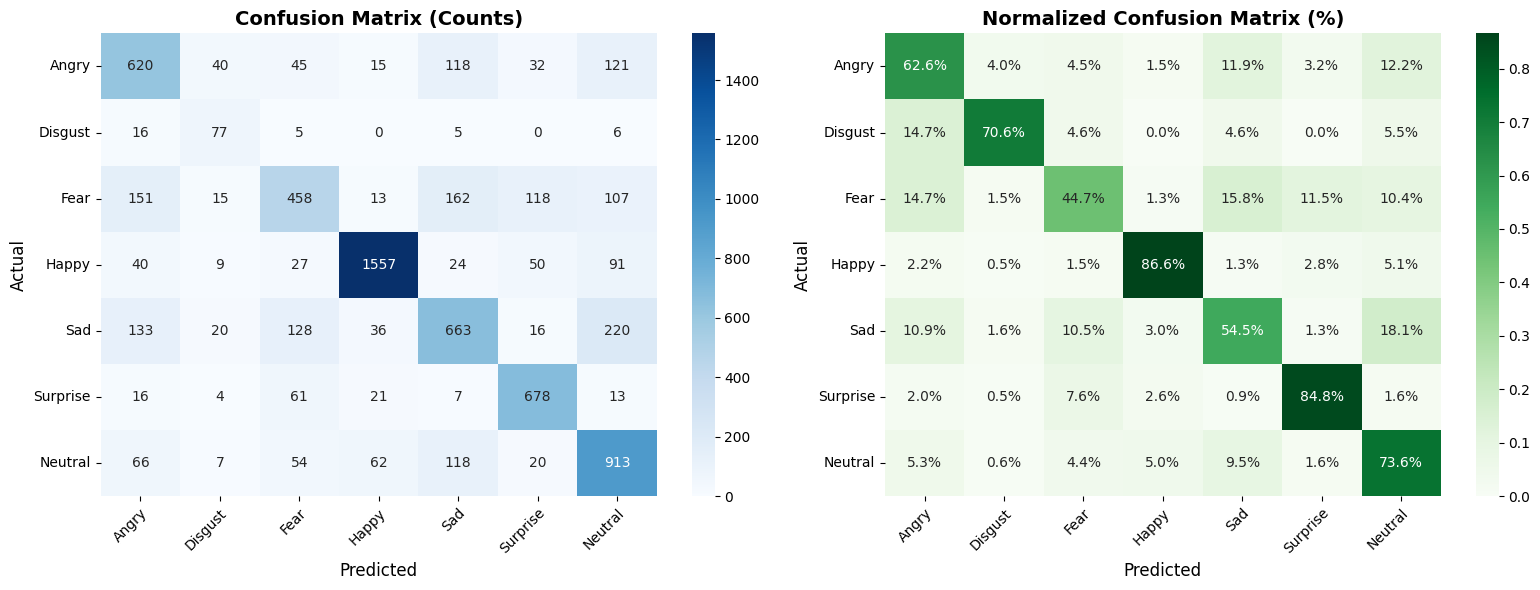

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Determine the best model to use for evaluation
# (Replicates the logic you already have)
from tensorflow.keras.models import load_model
import os

if os.path.exists('/kaggle/working/best_model_v2.keras'):
    model = load_model('/kaggle/working/best_model_v2.keras')
    print(" Evaluating best_model_v2.keras (69.18%)")
else:
    model = load_model('/kaggle/working/best_model.keras')
    print(" Evaluating best_model.keras (67.78%)")

# Predict on the entire validation set
val_predictions = model.predict(X_val)
y_pred = np.argmax(val_predictions, axis=1)
y_true = np.argmax(y_val, axis=1)

# Create a mapping from label index to emotion name
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy',
               4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
emotion_labels = list(emotion_map.values())

# 1. Detailed Classification Report
print("\n" + "="*50)
print(" DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=emotion_labels, digits=4))

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(" Raw Confusion Matrix:")
print(cm)

# 3. Visualizing Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Standard Confusion Matrix (Counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=emotion_labels, yticklabels=emotion_labels)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Predicted", fontsize=12)
axes[0].set_ylabel("Actual", fontsize=12)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(axes[0].get_yticklabels(), rotation=0)

# Plot 2: Normalized Confusion Matrix (Percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens', ax=axes[1],
            xticklabels=emotion_labels, yticklabels=emotion_labels)
axes[1].set_title("Normalized Confusion Matrix (%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Predicted", fontsize=12)
axes[1].set_ylabel("Actual", fontsize=12)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Total misclassified images in validation set: 2212 out of 7178


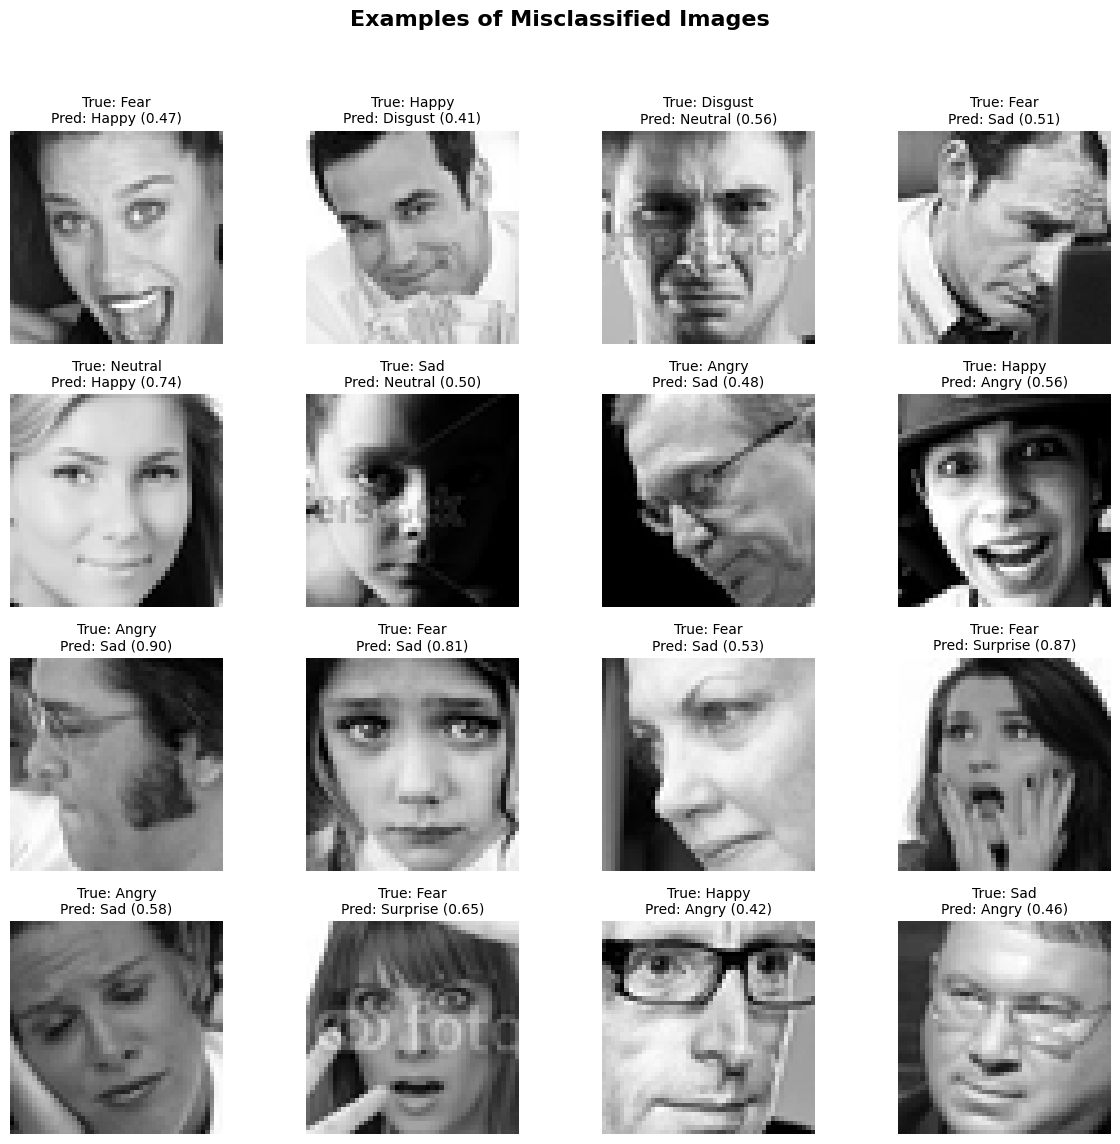

Indices of misclassified images (first 16 shown): [5, 16, 18, 19, 20, 21, 22, 26, 29, 31, 35, 38, 42, 44, 45, 47]


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# Ensure the same model is loaded as in Cell 1
if os.path.exists('/kaggle/working/best_model_v2.keras'):
    model = load_model('/kaggle/working/best_model_v2.keras')
else:
    model = load_model('/kaggle/working/best_model.keras')

# Get predictions (if not already done in a previous cell run)
val_predictions = model.predict(X_val)
y_pred = np.argmax(val_predictions, axis=1)
y_true = np.argmax(y_val, axis=1)

emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy',
               4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Find indices of misclassified images
misclassified_indices = np.where(y_pred != y_true)[0]
print(f"Total misclassified images in validation set: {len(misclassified_indices)} out of {len(y_true)}")

# If there are no misclassifications, inform the user.
if len(misclassified_indices) == 0:
    print("\n Congratulations! The model classified all validation images correctly. No error analysis to show.")
else:
    # Display the first 16 misclassified images (adjust n as needed)
    n = 16
    num_misclassified = len(misclassified_indices)
    samples_to_display = min(n, num_misclassified)
    
    # Plot the misclassified images
    fig, axes = plt.subplots(int(np.sqrt(samples_to_display)), int(np.sqrt(samples_to_display)), figsize=(12, 12))
    axes = axes.ravel()

    for i in range(samples_to_display):
        idx = misclassified_indices[i]
        axes[i].imshow(X_val[idx].reshape(48, 48), cmap='gray')
        true_label = emotion_map[y_true[idx]]
        pred_label = emotion_map[y_pred[idx]]
        confidence = np.max(val_predictions[idx])
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})", fontsize=10)
        axes[i].axis('off')

    # Hide any unused subplots
    for i in range(samples_to_display, len(axes)):
        axes[i].axis('off')

    plt.suptitle("Examples of Misclassified Images", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Print the specific indices of misclassified images for potential further analysis
    print(f"Indices of misclassified images (first {samples_to_display} shown): {misclassified_indices[:samples_to_display].tolist()}")

 Using best_model_v2.keras (69.18%)

 Looking for images in: /kaggle/input/datasets/salahzaoui/images

──────────────────────────────────────────────────
 anger.jpg
──────────────────────────────────────────────────
   Face detected



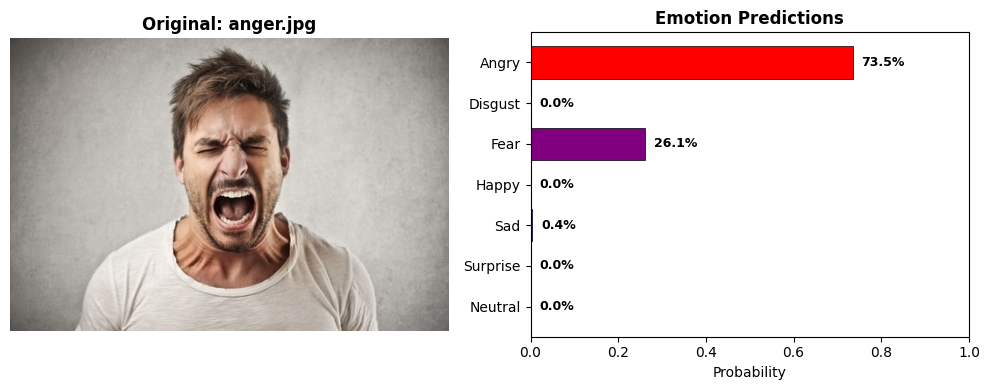

   Results (top 3):
   1. Angry      | ██████████████████████ | 73.5%  TRUE
   2. Fear       | ███████ | 26.1%
   3. Sad        |  | 0.4%

    Top Prediction: Angry (73.5%)
    Expected: Anger.jpg

──────────────────────────────────────────────────
 disgust.jpg
──────────────────────────────────────────────────
   Face detected



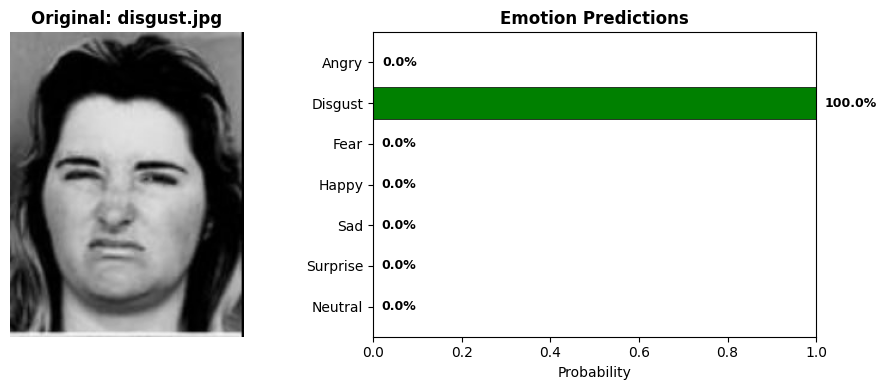

   Results (top 3):
   1. Disgust    | █████████████████████████████ | 100.0%  TRUE
   2. Angry      |  | 0.0%
   3. Sad        |  | 0.0%

    Top Prediction: Disgust (100.0%)
    Expected: Disgust.jpg

──────────────────────────────────────────────────
 fear.jpg
──────────────────────────────────────────────────
   Face detected



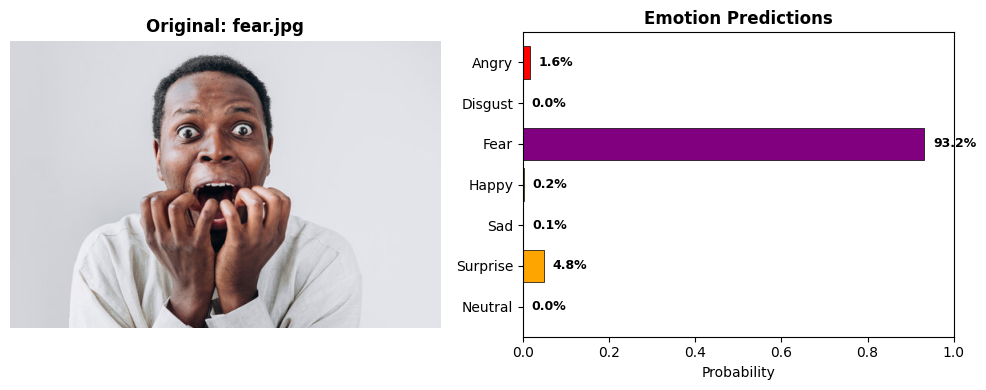

   Results (top 3):
   1. Fear       | ███████████████████████████ | 93.2%  TRUE
   2. Surprise   | █ | 4.8%
   3. Angry      |  | 1.6%

    Top Prediction: Fear (93.2%)
    Expected: Fear.jpg

──────────────────────────────────────────────────
 happy.jpg
──────────────────────────────────────────────────
   Face detected



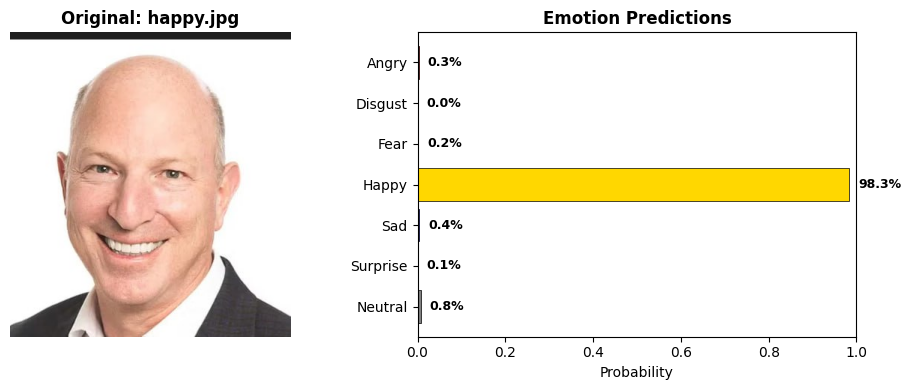

   Results (top 3):
   1. Happy      | █████████████████████████████ | 98.3%  TRUE
   2. Neutral    |  | 0.8%
   3. Sad        |  | 0.4%

    Top Prediction: Happy (98.3%)
    Expected: Happy.jpg

──────────────────────────────────────────────────
 sad.jpg
──────────────────────────────────────────────────
   Face detected



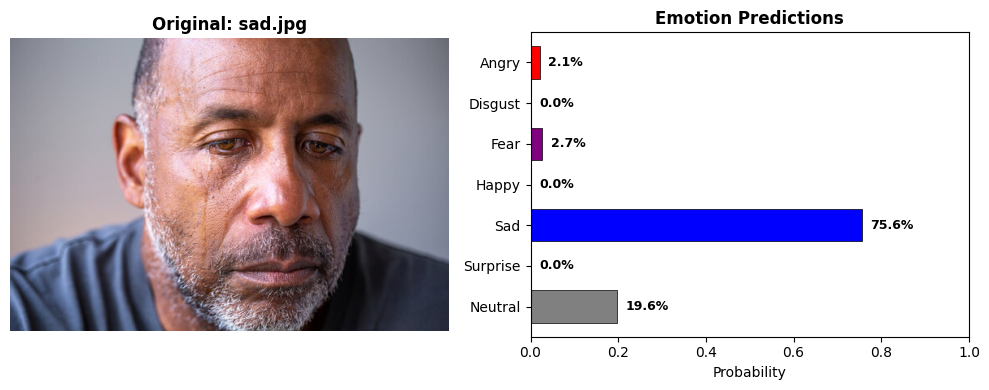

   Results (top 3):
   1. Sad        | ██████████████████████ | 75.6%  TRUE
   2. Neutral    | █████ | 19.6%
   3. Fear       |  | 2.7%

    Top Prediction: Sad (75.6%)
    Expected: Sad.jpg

──────────────────────────────────────────────────
 surprise.jpg
──────────────────────────────────────────────────
   Face detected



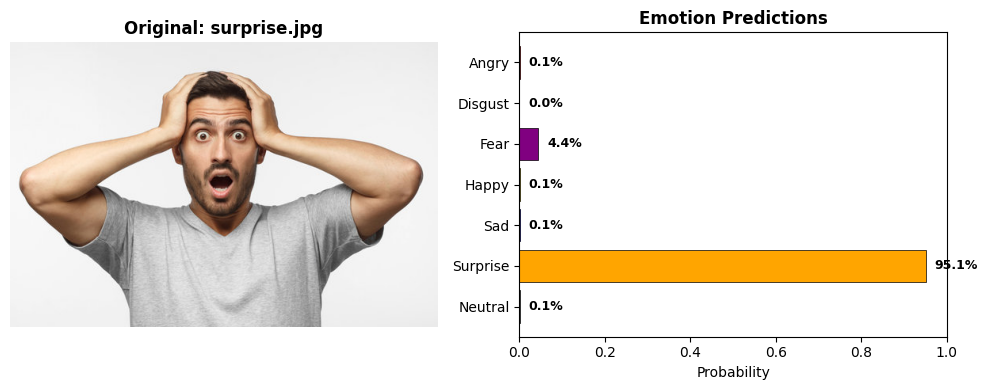

   Results (top 3):
   1. Surprise   | ████████████████████████████ | 95.1%  TRUE
   2. Fear       | █ | 4.4%
   3. Angry      |  | 0.1%

    Top Prediction: Surprise (95.1%)
    Expected: Surprise.jpg

──────────────────────────────────────────────────
 neutral.jpg
──────────────────────────────────────────────────
   Face detected



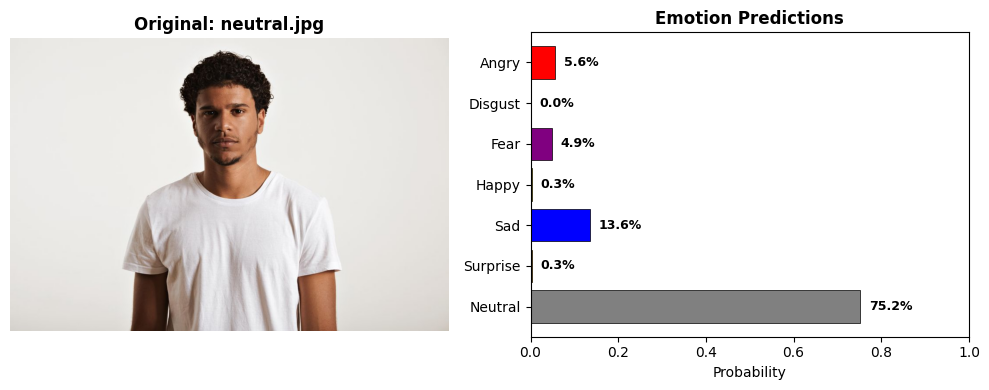

   Results (top 3):
   1. Neutral    | ██████████████████████ | 75.2%  TRUE
   2. Sad        | ████ | 13.6%
   3. Angry      | █ | 5.6%

    Top Prediction: Neutral (75.2%)
    Expected: Neutral.jpg

 Testing complete!


In [39]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to preprocess image for prediction
def preprocess_image(image_path):
    """
    Preprocess an image for emotion prediction.
    - Reads image
    - Converts to grayscale
    - Detects face (if possible) or uses whole image
    - Resizes to 48x48
    - Normalizes to [0,1]
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Try to detect face
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = gray[y:y+h, x:x+w]
        detected = "Face detected"
    else:
        face = gray
        detected = "No face detected (using whole image)"
    
    # Resize to 48x48
    face = cv2.resize(face, (48, 48))
    
    # Normalize
    face = face / 255.0
    face = np.expand_dims(face, axis=(0, -1))
    
    return face, img, detected

# Load the best model
from tensorflow.keras.models import load_model
import os

# Auto-detect best model
if os.path.exists('/kaggle/working/best_model_v2.keras'):
    model = load_model('/kaggle/working/best_model_v2.keras')
    print(" Using best_model_v2.keras (69.18%)")
else:
    model = load_model('/kaggle/working/best_model.keras')
    print(" Using best_model.keras (67.78%)")

# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy',
               4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Folder containing test images
# CHANGE THIS PATH to your folder
test_folder = '/kaggle/input/datasets/salahzaoui/images'  # <-- CHANGE THIS

# If you uploaded images directly to kaggle working directory, use:
# test_folder = '/kaggle/working/'

print(f"\n Looking for images in: {test_folder}")
print("=" * 70)

# Expected image names
expected_images = ['anger.jpg', 'disgust.jpg', 'fear.jpg', 'happy.jpg', 
                   'sad.jpg', 'surprise.jpg', 'neutral.jpg']

# Colors for predictions
colors = ['red', 'green', 'purple', 'gold', 'blue', 'orange', 'gray']

# Test each image
for img_name in expected_images:
    img_path = os.path.join(test_folder, img_name)
    
    print(f"\n{'─' * 50}")
    print(f" {img_name}")
    print(f"{'─' * 50}")
    
    if not os.path.exists(img_path):
        print(f"  Image not found: {img_path}")
        continue
    
    try:
        # Preprocess and predict
        face, original_img, detection_status = preprocess_image(img_path)
        predictions = model.predict(face, verbose=0)[0]
        
        # Sort predictions
        sorted_indices = np.argsort(predictions)[::-1]
        
        print(f"   {detection_status}")
        print()
        
        # Display image and predictions side by side
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        # Original image
        axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original: {img_name}", fontsize=12, fontweight='bold')
        axes[0].axis('off')
        
        # Prediction bars
        bars = axes[1].barh(list(emotion_map.values())[::-1], 
                           predictions[::-1], 
                           color=colors[::-1],
                           edgecolor='black', linewidth=0.5)
        axes[1].set_title("Emotion Predictions", fontsize=12, fontweight='bold')
        axes[1].set_xlabel("Probability", fontsize=10)
        axes[1].set_xlim(0, 1)
        
        # Add value labels
        for i, (bar, pred) in enumerate(zip(bars, predictions[::-1])):
            axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                        f'{pred:.1%}', va='center', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed results
        print("   Results (top 3):")
        for i in range(3):
            idx = sorted_indices[i]
            prob = predictions[idx]
            emotion = emotion_map[idx]
            bar = "█" * int(prob * 30)
            marker = "  TRUE" if i == 0 else ""
            print(f"   {i+1}. {emotion:10s} | {bar} | {prob:.1%}{marker}")
        
        # Print summary
        top_emotion = emotion_map[sorted_indices[0]]
        top_prob = predictions[sorted_indices[0]]
        expected_emotion = img_name.replace('.png', '').capitalize()
        
        print(f"\n    Top Prediction: {top_emotion} ({top_prob:.1%})")
        print(f"    Expected: {expected_emotion}")
        
        
    except Exception as e:
        print(f"    Error processing image: {e}")

print(f"\n{'=' * 70}")
print(" Testing complete!")

 Dataset Statistics
Total samples: 35887
Number of unique classes: 7
Classes and their distribution:
emotion_name
Happy       8989
Neutral     6198
Sad         6077
Fear        5121
Angry       4953
Surprise    4002
Disgust      547
Name: count, dtype: int64

Usage Split:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


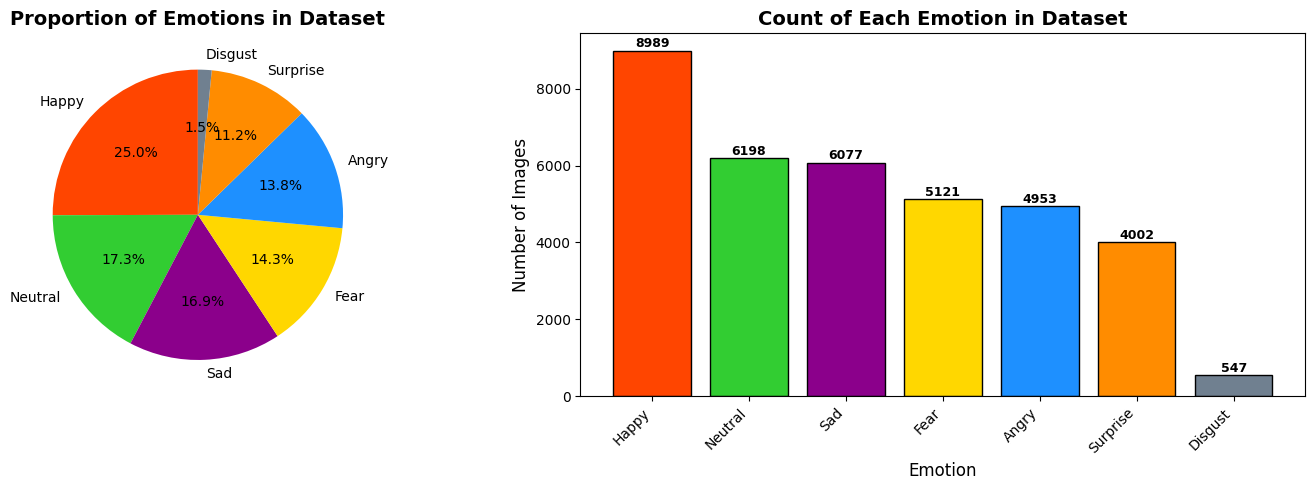

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is still in memory, if not, reload it:
# df = pd.read_csv('/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv')

emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy',
               4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
df['emotion_name'] = df['emotion'].map(emotion_map)

print("="*40)
print(" Dataset Statistics")
print("="*40)
print(f"Total samples: {len(df)}")
print(f"Number of unique classes: {df['emotion'].nunique()}")
print(f"Classes and their distribution:")
print(df['emotion_name'].value_counts())
print("\nUsage Split:")
print(df['Usage'].value_counts())

# --- Visualization 1: Distribution of Emotions ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart to show proportions
emotion_counts = df['emotion_name'].value_counts()
colors = ['#FF4500', '#32CD32', '#8B008B', '#FFD700', '#1E90FF', '#FF8C00', '#708090']
axes[0].pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Proportion of Emotions in Dataset', fontsize=14, fontweight='bold')

# Bar chart for count comparison
ax = axes[1]
bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black')
ax.set_title('Count of Each Emotion in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel("Emotion", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Annotate bar chart with counts
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()